# Chest X-Ray Pneumonia Classification

A convolutional neural network (CNN) that classifies chest X-ray images as either **Normal** or **Pneumonia**.

**Dataset:** Kaggle Chest X-Ray Images (Pneumonia) dataset, which provides pre-split `train/` and `test/` folders, each containing `NORMAL` and `PNEUMONIA` subfolders of grayscale JPEG images.

**Approach:**
- Images are loaded as grayscale, resized to 150x150, and normalized to a 0-1 pixel range.
- A CNN with three convolutional blocks extracts visual features, followed by a dense classification head.
- The training set is imbalanced (~3:1 Pneumonia to Normal), so class weighting is used to prevent the model from defaulting to the majority class.
- EarlyStopping monitors validation loss to prevent overfitting and automatically restores the best-performing weights.

**Evaluation:** Model performance is measured on a held-out test set using accuracy, a confusion matrix, and per-class precision/recall/F1 — important here since overall accuracy alone can be misleading on an imbalanced dataset.


## 1. Imports

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

## 2. Define Dataset and Image Size

In [2]:
TRAIN_DIR = "xray/chest_xray/train"
TEST_DIR = "xray/chest_xray/test"
categories = ["Normal", "Pneumonia"]
IMG_SIZE =150

## 3. Preprocess Data

In [3]:
def load_data(data_dir, categories, img_size):
    X, y =[],[]
    for label, category in enumerate(categories):
        path = os.path.join(data_dir, category)
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
              continue
            img = cv2.resize(img, (img_size, img_size))
            img = img.astype(np.float32) / 255.0
            img = np.expand_dims(img, axis=-1)
            X.append(img)
            y.append(label)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

X_train_full, y_train_full = load_data(TRAIN_DIR, categories, IMG_SIZE)
X_test, y_test = load_data(TEST_DIR, categories, IMG_SIZE)

print("Train shape:", X_train_full.shape)
print("Test shape: ", X_test.shape)
print("Train class counts:", {c: int(np.sum(y_train_full == i)) for i, c in enumerate(categories)})
print("Test class counts: ", {c: int(np.sum(y_test == i)) for i, c in enumerate(categories)})

Train shape: (5232, 150, 150, 1)
Test shape:  (624, 150, 150, 1)
Train class counts: {'Normal': 1349, 'Pneumonia': 3883}
Test class counts:  {'Normal': 234, 'Pneumonia': 390}


## 4. Train / Validation Split
Take a validation set out of the training data only (the test set is already separate and stays untouched until final evaluation). The validation set is used during training to monitor generalization and decide when to stop, without contaminating the test set.

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, stratify=y_train_full, random_state=SEED
)

print("Train shape:", X_train.shape)
print("Val shape:  ", X_val.shape)
print("Test shape: ", X_test.shape)

Train shape: (4447, 150, 150, 1)
Val shape:   (785, 150, 150, 1)
Test shape:  (624, 150, 150, 1)


## 5. Compute Class Weights

In [5]:
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight = dict(enumerate (class_weight_values))
print ("Class weights:", class_weight)

Class weights: {0: np.float64(1.9385353095030515), 1: np.float64(0.6737878787878788)}


## 6. Build The Model

In [6]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),MaxPooling2D(2,2),
    Conv2D(64, (3, 3), activation='relu'),MaxPooling2D(2,2),
    Conv2D(128, (3, 3), activation='relu'),MaxPooling2D(2,2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense (len(categories), activation='softmax')
])
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer ='adam',
    metrics=['accuracy']
)
model.summary()

C:\Users\pc\miniconda3\envs\ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,034 (18.42 MB)

 Trainable params: 4,828,034 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Training
Train with EarlyStopping, which halts training once validation loss stops improving for 3 consecutive epochs and restores the best-performing weights. Class weights are applied during training to counter the class imbalance

In [7]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
]
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 53s 356ms/step - accuracy: 0.8167 - loss: 0.3469 - val_accuracy: 0.9299 - val_loss: 0.1885
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 51s 366ms/step - accuracy: 0.9418 - loss: 0.1588 - val_accuracy: 0.9490 - val_loss: 0.1584
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 53s 381ms/step - accuracy: 0.9555 - loss: 0.1225 - val_accuracy: 0.9592 - val_loss: 0.1109
Epoch 4/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 51s 368ms/step - accuracy: 0.9667 - loss: 0.0940 - val_accuracy: 0.9682 - val_loss: 0.0934
Epoch 5/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 50s 362ms/step - accuracy: 0.9696 - loss: 0.0848 - val_accuracy: 0.9707 - val_loss: 0.0832
Epoch 6/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 51s 366ms/step - accuracy: 0.9771 - loss: 0.0655 - val_accuracy: 0.9656 - val_loss: 0.1139
Epoch 7/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 50s 360ms/step - accuracy: 0.9773 - loss: 0.0630 - val_accuracy: 0.9618 - val_loss: 0.1532
Epoch 8/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 52s 370ms/step - accuracy: 0.9789 - loss: 0

## 8. Model Evaluation

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.8670 - loss: 0.4241
Test Accuracy: 0.8670


## 9. Plot Results

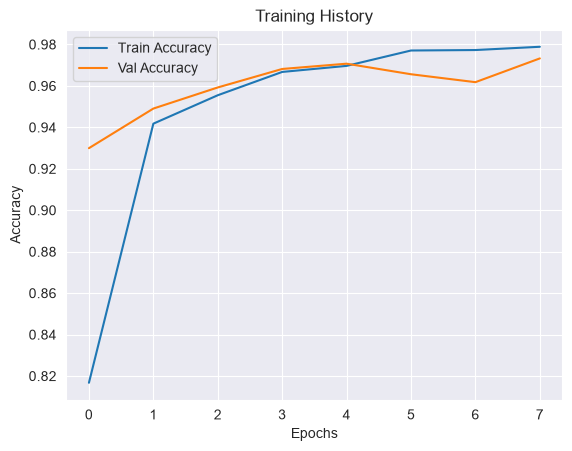

In [9]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training History')
plt.show()

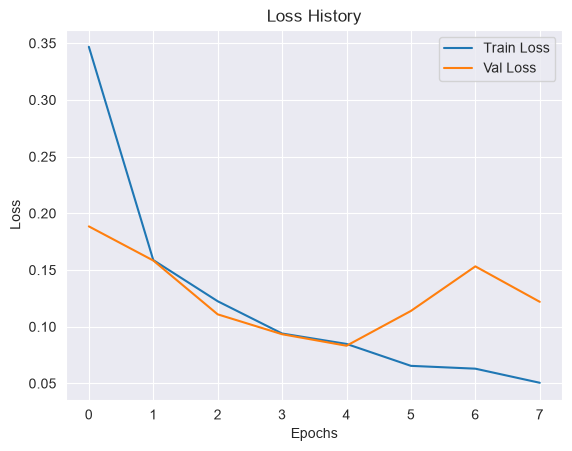

In [10]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss History')
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step


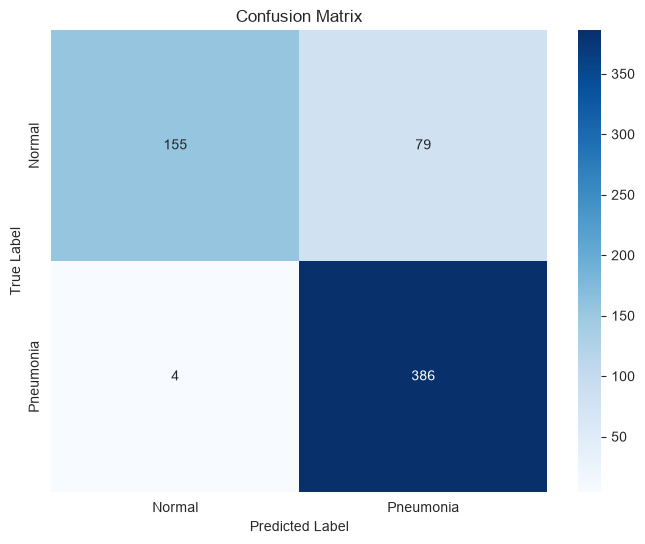

              precision    recall  f1-score   support

      Normal       0.97      0.66      0.79       234
   Pneumonia       0.83      0.99      0.90       390

    accuracy                           0.87       624
   macro avg       0.90      0.83      0.85       624
weighted avg       0.88      0.87      0.86       624



In [11]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred_classes, target_names=categories))

In [12]:
model.save("chest_xray_classifier.keras")

## 10. Predict on a New Image

In [13]:
def predict_image(img_path, model, categories, img_size=IMG_SIZE):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {img_path}")
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)
    img = np.expand_dims(img, axis=0)
    prediction = model.predict(img)
    class_index = np.argmax(prediction)
    confidence = float(np.max(prediction))
    return categories[class_index], confidence

In [19]:
img_path = r"C:\Users\pc\Downloads\test5.jpg"
print("Prediction:", predict_image(img_path, model, categories))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Prediction: ('Pneumonia', 0.9900457262992859)



**Limitations:** The model is trained and evaluated on images from a single dataset source. Performance on X-rays from other hospitals, scanners, or imaging pipelines (domain shift) has not been tested and may be lower than the in-distribution test accuracy suggests.

By Methuki De Silva